---
title: "scikit-learn vs cuML"
subtitle: "scikit-learn vs cuML comparison on basic ML methods."
author: "Author: Ignacio Masari (EODC)"
tags: [scikit-learn, cuML, Machine Learning, GPU]
thumbnail: ../img/DE_logo.jpg
license: MIT
copyright: "© 2026 EODC GmbH."
---

# scikit-learn vs cuML

Compare CPU scikit-learn estimators with GPU-backed cuML equivalents using similar APIs.

| | |
|---|---|
| **Data** | Synthetic classification and clustering datasets |
| **Task** | Random Forest, KNN, K-Means |
| **Framework** | scikit-learn + cuML |
| **Expected runtime** | ~2 min on CPU &nbsp;|&nbsp; <1 min on GPU |

In [1]:
import sklearn, cuml
import numpy as np, matplotlib.pyplot as plt, time
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
)

print(f"scikit-learn : {sklearn.__version__}")
print(f"cuML         : {cuml.__version__}")

scikit-learn : 1.8.0
cuML         : 25.04.00


## Dataset

In [2]:
X, y = make_classification(
    n_samples=200_000, n_features=20, n_informative=10,
    n_classes=3, n_clusters_per_class=2, random_state=42,
)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr).astype("float32")
X_te_s = scaler.transform(X_te).astype("float32")
y_tr_f = y_tr.astype("float32")
y_te_f = y_te.astype("float32")
print(f"Train: {X_tr_s.shape}  |  Test: {X_te_s.shape}")

Train: (160000, 20)  |  Test: (40000, 20)


## 1. Random Forest — sklearn (CPU) vs cuML (GPU)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from cuml.ensemble import RandomForestClassifier as cuRF

t0 = time.perf_counter()
rf_cpu = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_cpu.fit(X_tr_s, y_tr)
t_cpu = time.perf_counter() - t0
acc_cpu = rf_cpu.score(X_te_s, y_te)

t0 = time.perf_counter()
rf_gpu = cuRF(n_estimators=100, random_state=42)
rf_gpu.fit(X_tr_s, y_tr_f)
t_gpu = time.perf_counter() - t0
acc_gpu = float(rf_gpu.score(X_te_s, y_te_f))

print(f"{'':20s}  {'Time':>8s}  {'Accuracy':>10s}")
print(f"{'sklearn (CPU)':20s}  {t_cpu:>7.2f}s  {acc_cpu:>10.4f}")
print(f"{'cuML    (GPU)':20s}  {t_gpu:>7.2f}s  {acc_gpu:>10.4f}  (speedup {t_cpu/t_gpu:.1f}x)")

/opt/conda/lib/python3.12/site-packages/cuml/internals/api_decorators.py:317: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)


                          Time    Accuracy
sklearn (CPU)           15.50s      0.9508
cuML    (GPU)            1.20s      0.9338  (speedup 12.9x)


### Random Forest scaling — speedup grows with rows

/opt/conda/lib/python3.12/site-packages/cuml/internals/api_decorators.py:317: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)


n= 25,000  CPU=  0.96s  GPU= 0.20s  speedup=  4.7x


/opt/conda/lib/python3.12/site-packages/cuml/internals/api_decorators.py:317: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)


n= 50,000  CPU=  2.13s  GPU= 0.23s  speedup=  9.4x


/opt/conda/lib/python3.12/site-packages/cuml/internals/api_decorators.py:317: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)


n=100,000  CPU=  4.73s  GPU= 0.39s  speedup= 12.2x


/opt/conda/lib/python3.12/site-packages/cuml/internals/api_decorators.py:317: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)


n=250,000  CPU= 14.00s  GPU= 0.79s  speedup= 17.7x


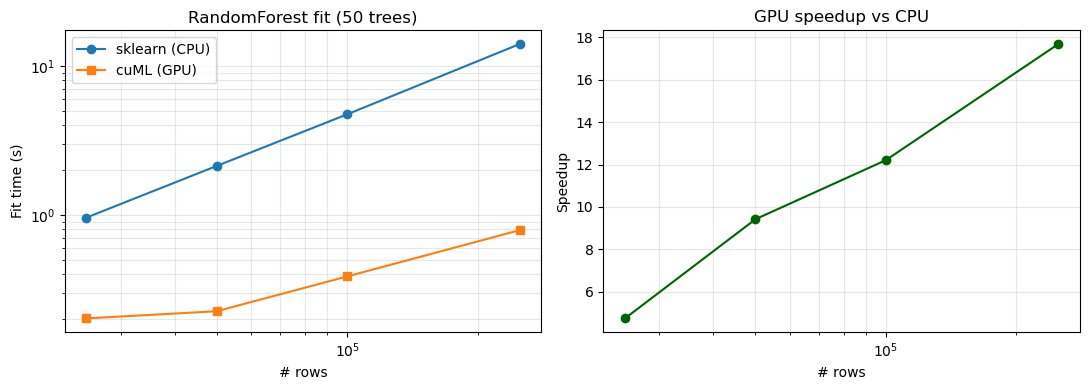

In [4]:
sizes = [25_000, 50_000, 100_000, 250_000]
cpu_t, gpu_t = [], []
for n in sizes:
    Xs, ys = make_classification(n_samples=n, n_features=20, n_informative=10,
                                  n_classes=3, n_clusters_per_class=2, random_state=42)
    Xs = Xs.astype("float32"); ys_f = ys.astype("float32")

    t0 = time.perf_counter()
    RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42).fit(Xs, ys)
    cpu_t.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    cuRF(n_estimators=50, random_state=42).fit(Xs, ys_f)
    gpu_t.append(time.perf_counter() - t0)
    print(f"n={n:>7,d}  CPU={cpu_t[-1]:6.2f}s  GPU={gpu_t[-1]:5.2f}s  speedup={cpu_t[-1]/gpu_t[-1]:5.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(sizes, cpu_t, "o-", label="sklearn (CPU)")
axes[0].loglog(sizes, gpu_t, "s-", label="cuML (GPU)")
axes[0].set_xlabel("# rows"); axes[0].set_ylabel("Fit time (s)")
axes[0].set_title("RandomForest fit (50 trees)"); axes[0].legend(); axes[0].grid(True, which="both", alpha=0.3)
axes[1].semilogx(sizes, [c/g for c, g in zip(cpu_t, gpu_t)], "o-", color="darkgreen")
axes[1].set_xlabel("# rows"); axes[1].set_ylabel("Speedup")
axes[1].set_title("GPU speedup vs CPU"); axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 2. K-Nearest Neighbours — quadratic distance computation

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from cuml.neighbors import KNeighborsClassifier as cuKNN

t0 = time.perf_counter()
knn_cpu = KNeighborsClassifier(n_neighbors=15, n_jobs=-1).fit(X_tr_s, y_tr)
_ = knn_cpu.predict(X_te_s[:10000])
t_cpu = time.perf_counter() - t0

t0 = time.perf_counter()
knn_gpu = cuKNN(n_neighbors=15).fit(X_tr_s, y_tr_f)
_ = knn_gpu.predict(X_te_s[:10000])
t_gpu = time.perf_counter() - t0
print(f"kNN  CPU: {t_cpu:6.2f}s   GPU: {t_gpu:6.2f}s   speedup: {t_cpu/t_gpu:.1f}x")

kNN  CPU:   1.61s   GPU:   0.19s   speedup: 8.5x


## 3. K-Means clustering

KMeans  sklearn=  0.49s   cuML=  0.17s   speedup=2.9x


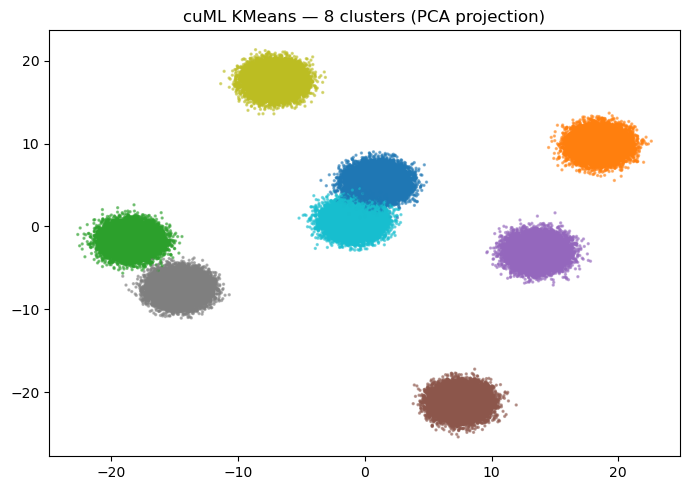

In [6]:
from cuml.cluster import KMeans as cuKMeans
from cuml.decomposition import PCA as cuPCA
from cuml.datasets import make_blobs as cu_make_blobs
from sklearn.cluster import KMeans as skKMeans

X_gpu, y_gpu = cu_make_blobs(n_samples=200_000, centers=8, n_features=20, random_state=42)
X_cpu = X_gpu.get() if hasattr(X_gpu, "get") else np.asarray(X_gpu)

t0 = time.perf_counter()
skKMeans(n_clusters=8, n_init=3, random_state=42).fit(X_cpu)
t_cpu = time.perf_counter() - t0

kmeans = cuKMeans(n_clusters=8, n_init=3, random_state=42)
t0 = time.perf_counter()
kmeans.fit(X_gpu)
t_gpu = time.perf_counter() - t0
print(f"KMeans  sklearn={t_cpu:6.2f}s   cuML={t_gpu:6.2f}s   speedup={t_cpu/t_gpu:.1f}x")

# 2D PCA projection for visualisation
pca = cuPCA(n_components=2, output_type="numpy")
X_2d = pca.fit_transform(X_gpu)
labels = kmeans.labels_.get()

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=2, alpha=0.5)
plt.title("cuML KMeans — 8 clusters (PCA projection)"); plt.tight_layout(); plt.show()